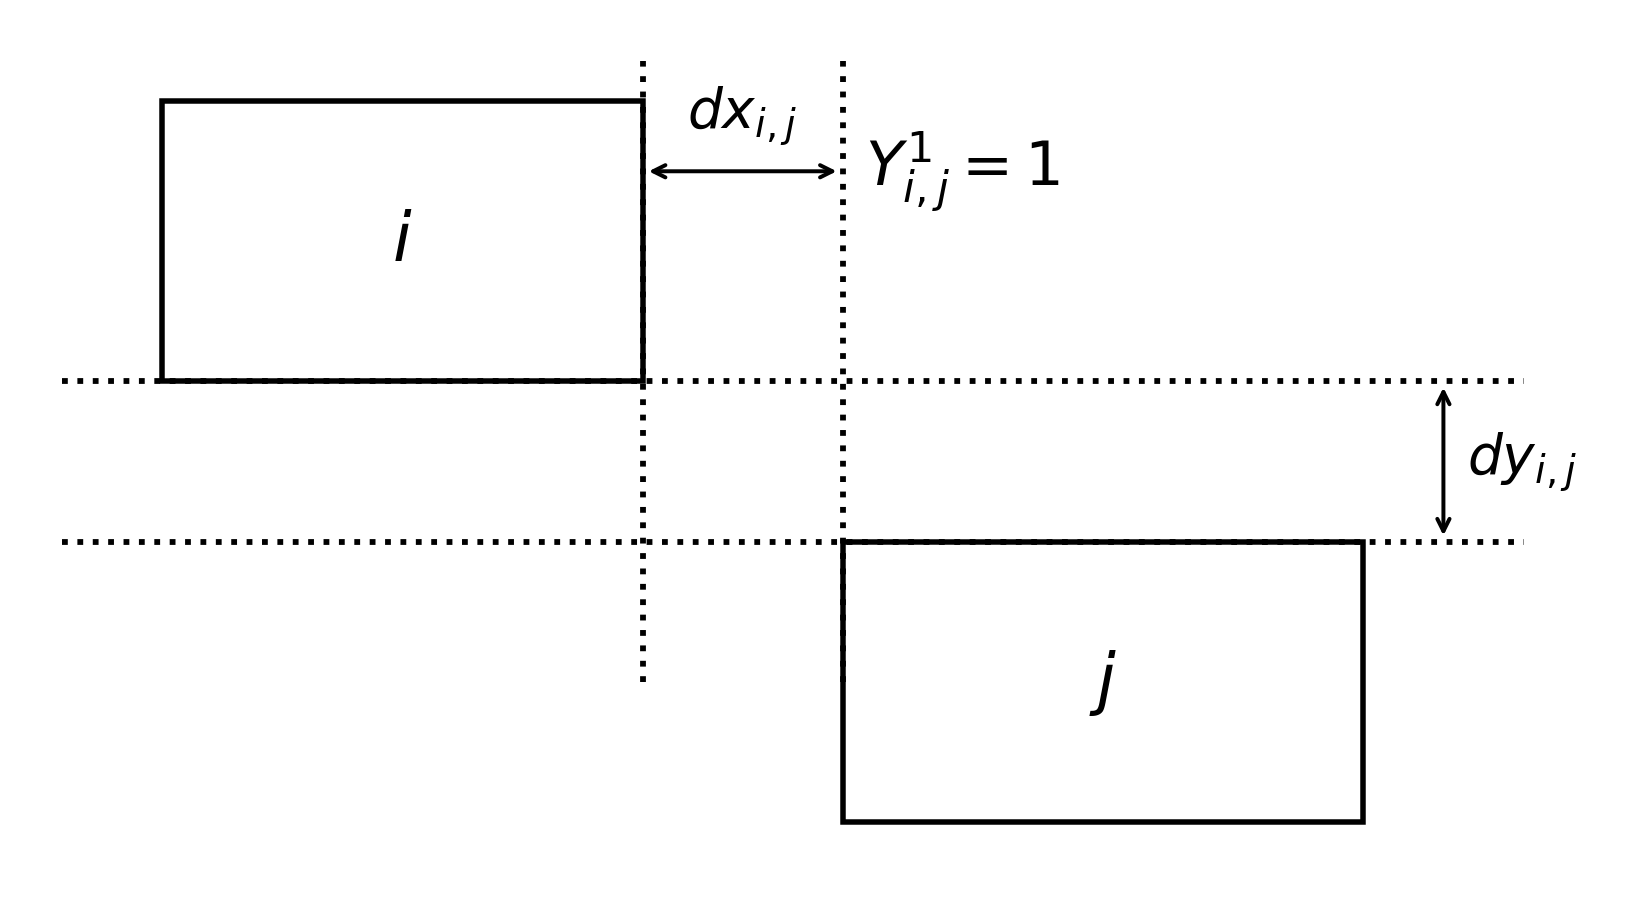

\begin{gather}
\min \; l_f + w_f + \sum_{i,j} c_{i,j}( dx_{i,j} + dy_{i,j}) \\
\text{Minimize the sum of facility dimensions and weighted Manhattan distances between blocks}\\
\textrm{s.t.} \;l_f \ge x_i + l_i \; \forall  i \in  N \\
\text{The length of the facility contains all blocks}\\ 
w_f \ge y_i + w_i \; \forall  i \in  N \\ 
\text{The width of the facility contains all blocks}\\
dx_{i,j} \ge x_i - (x_j + l_j), \quad dx_{i,j} \ge x_j - (x_i + l_i) \; \forall i,j \in N,\, j<i \\
dy_{i,j} \ge y_i - (y_j + w_j), \quad dy_{i,j} \ge y_j - (y_i + w_i) \; \forall i,j \in N,\, j<i \\
\text{Rectilinear edge gaps (0 when blocks overlap on that axis), defined globally — not inside the disjunction}\\
x_i \le UB, \; y_i \le UB \; \forall i \in  N, \quad UB = \sum_{i} \max(l_i,w_i) \\ 
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_i + l_i + d_{i,j} \le x_j\\ 
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
x_j + l_j + d_{i,j} \le x_i\\ 
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i + w_i + d_{i,j} \le y_j \\ 
\text{$i$ is below $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j + w_j + d_{i,j} \le y_i \\ 
\text{$i$ is above $j$}
\end{array}
\right] \\
\text{Non-overlap: exactly one separation per pair, with the minimum clearance $d_{i,j}$ built in}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \\ 
\\
l_f,w_f,l_i,w_i,x_i,y_i,dx_{i,j},dy_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}

Distance is handled by the global $dx,dy$ constraints, so the disjunction decides only non-overlap, never cost — this keeps the objective independent of which spatial relation is chosen, and avoids the costly *continuous* degeneracy that coupling distance into the disjuncts would create. Symmetry breaking (when `sym=1`) anchors block 1 left-of-and-below block 2: $x_1 + l_1/2 \le x_2 + l_2/2$ and $y_1 + w_1/2 \le y_2 + w_2/2$.

In [1]:
import random
import pandas as pd
import visuals as vs
from pyomo.environ import (ConcreteModel, NonNegativeReals, Objective, Param,
                           Set, SolverFactory, TransformationFactory, Var, value, RangeSet)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe



def create_model(n,w_0,l_0,c_0,d_0,rotate=0,sym=0):

    ## Model
    m = ConcreteModel()

    ## Sets
    m.n = Set(ordered=True, initialize=RangeSet(1, n) )
    def rec_pairs_filter(m, i, j):
        return i > j
    m.p = Set(initialize=m.n * m.n,  dimen=2, filter=rec_pairs_filter)

    ## Parameters
    # Width and length of each rectangle
    m.w0 = Param(m.n, initialize= w_0)
    m.l0 = Param(m.n, initialize = l_0)
    #cost
    m.c = Param(m.p, initialize = c_0 )
    #minimum separation distance
    m.d = Param(m.p, initialize = d_0 )

    # Upperbound
    m.UB = Param(initialize=sum(max([m.l0[i],m.w0[i]]) for i in m.n))

    ## Variables
    # x (length) and y (width) coordinates of each rectangle's lower-left corner
    m.x = Var(m.n,bounds=(0,m.UB))
    m.y = Var(m.n,bounds=(0,m.UB))
    # rectilinear edge gaps between each pair (horizontal dx, vertical dy)
    m.dx = Var(m.p,bounds=(0,m.UB))
    m.dy = Var(m.p,bounds=(0,m.UB))
    m.l =Var(m.n,bounds=(0,m.UB))
    m.w = Var(m.n,bounds=(0,m.UB))

    # facility width and length
    m.l_f = Var(within=NonNegativeReals)
    m.w_f = Var(within=NonNegativeReals)

    ## Constraints
    @m.Constraint(m.n)
    def facility_length(m, i):
        return m.l_f >= m.x[i] + m.l[i]
    @m.Constraint(m.n)
    def facility_width(m, i):
        return m.w_f >= m.y[i] + m.w[i]

    # Rectilinear edge gaps, defined GLOBALLY (not inside the disjunction) so
    # the objective never depends on which spatial relation is selected. Each
    # is minimized, so it settles to the true clearance (0 if blocks overlap
    # on that axis).
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i,j] >= m.x[i] - (m.x[j] + m.l[j])
    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i,j] >= m.x[j] - (m.x[i] + m.l[i])
    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i,j] >= m.y[i] - (m.y[j] + m.w[j])
    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i,j] >= m.y[j] - (m.y[i] + m.w[i])


    if sym==1:
        @m.Constraint()
        #break horizontal symmetry
        def sym_1(m):
            return m.x[1] + m.l[1]/2 <= m.x[2] + m.l[2] /2

        @m.Constraint()
        #break vertical symmetry
        def sym_2(m):
            return m.y[1] + m.w[1]/2 <= m.y[2] + m.w[2] /2


    ## Objective
    m.obj = Objective(expr=m.l_f+m.w_f +   sum( m.c[i,j] * (m.dx[i,j] + m.dy[i,j]) for i,j in m.p)    )

    # Non-overlap: exactly one of four separations per pair, each a single
    # inequality with the minimum clearance d baked in.
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.l[i] + m.d[i,j] <= m.x[j]],   # i left of j
            [m.x[j] + m.l[j] + m.d[i,j] <= m.x[i]],   # i right of j
            [m.y[i] + m.w[i] + m.d[i,j] <= m.y[j]],   # i below j
            [m.y[j] + m.w[j] + m.d[i,j] <= m.y[i]],   # i above j
            ]
    if rotate ==1:
        @m.Disjunction(m.n)
        def rotate(m, i):
            return [
                [m.l[i] == m.l0[i],
                m.w[i] == m.w0[i] ],

                [m.l[i] == m.w0[i],
                m.w[i] == m.l0[i] ]     ]
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]
        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]
    return m

In [2]:
num =6
random.seed(1)
#random blocks
w_0 = {i: random.randint(1, 2) for i in range(1,num+1)}
l_0={i: random.randint(1, 2) for i in range(1,num+1)}

#random pipes
#c_0 = {(i,j):random.randint(1,10) for i in range(1,num+1) for j in range(1,num+1) if i > j}
#pipes to pipe rack only
c_0 = {(i,j):1 if j == 1 else 0 for i in range(1,num+1) for j in range(1,num+1) if i>j}   


#minimum dist

d_0 = {(i,j):1 for i in range(1,num+1) for j in range(1,num+1) if i > j}
   



In [3]:
m = create_model(num,w_0,l_0,c_0,d_0,rotate = 1,sym=1)
TransformationFactory('gdp.bigm').apply_to(m)
# Solve and print the solution.
# HiGHS is a free MILP solver (pip install highspy); the app itself uses Gurobi.
SolverFactory('appsi_highs').solve(m, tee=True)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms


MIP has 203 rows; 128 cols; 692 nonzeros; 72 integer variables (72 binary)
Coefficient ranges:
  Matrix  [5e-01, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+01]
  RHS     [1e+00, 2e+01]
Presolving model
197 rows, 102 cols, 640 nonzeros 0s
157 rows, 102 cols, 520 nonzeros 0s
Presolve reductions: rows 157(-46); columns 102(-26); nonzeros 520(-172) 

Solving MIP model with:
   157 rows
   102 cols (66 binary, 0 integer, 0 implied int., 36 continuous, 0 domain fixed)
   520 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  P

 L       0       0         0   0.00%   5               28                82.14%     1815    108      9       438     0.1s

Symmetry detection completed in 0.0s
Found 1 generator(s)

 L       0       0         0   0.00%   5               17                70.59%     1815     46      9       527     0.3s


 B     128      15        51   2.93%   5               17                70.59%     2200     65    392      5356     0.7s


 T     421      45       184   6.97%   6               17                64.71%     2635     95    963     10936     1.6s
 T     529      46       229   9.82%   6               16                62.50%     2791     63   1067     11700     1.6s


...

     14151     134      6921  82.96%   13              16                18.75%     2703    114   3398    196785    17.4s


 T   15551     122      7623  87.01%   13              16                18.75%     2669     80   3485    215327    18.9s


     19549       4      9649  99.26%   14.11111111     16                11.81%     2138     70   3663    269908    23.9s


     20051       0      9903 100.00%   16              16                 0.00%     2181     80   3950    275338    24.3s

Solving report
  Status            Optimal
  Primal bound      16
  Dual bound        16
  Gap               0% (tolerance: 0.01%)
  P-D integral      6.75781928795
  Solution status   feasible
                    16 (objective)
                    0 (bound viol.)
                    1.13020703907e-13 (int. viol.)
                    0 (row viol.)
  Timing            24.33
  Max sub-MIP depth 5
  Nodes             20051
  Repair LPs        0
  LP iterations     275338
                    4521 (strong br.)
                    27541 (separation)
                    15363 (heuristics)


{'Problem': [{'Lower bound': 15.999999999999721, 'Upper bound': 15.999999999999721, 'Number of objectives': 1, 'Number of constraints': 0, 'Number of variables': 0, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Termination message': 'TerminationCondition.optimal'}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

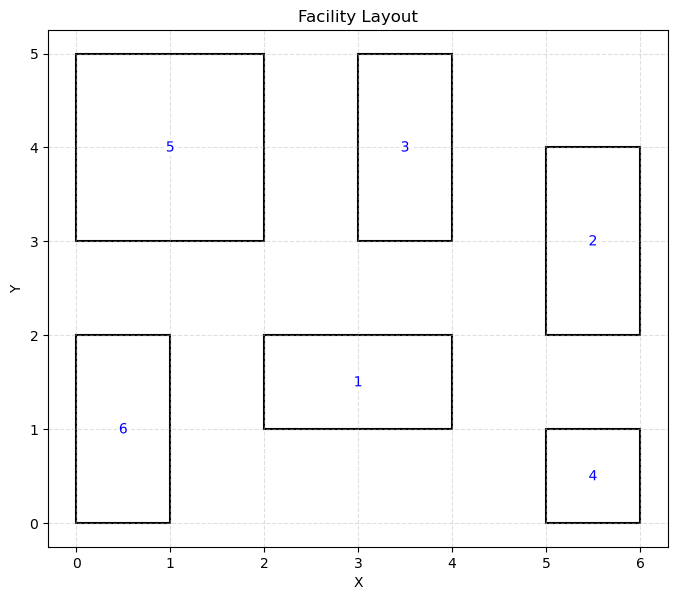

,Rectangle,X (Lower Left),Y (Lower Left),Length (X),Width (Y)
0,1,2,1,2,1
1,2,5,2,1,2
2,3,3,3,1,2
3,4,5,0,1,1
4,5,0,3,2,2
5,6,0,0,1,2


In [4]:
vs.plot_rect_layout(m, title="Facility Layout")
vs.rect_table(m,decimals = 0)

In [5]:
print(c_0)

{(2, 1): 1, (3, 1): 1, (3, 2): 0, (4, 1): 1, (4, 2): 0, (4, 3): 0, (5, 1): 1, (5, 2): 0, (5, 3): 0, (5, 4): 0, (6, 1): 1, (6, 2): 0, (6, 3): 0, (6, 4): 0, (6, 5): 0}
